# 04 - Phân tích văn bản

Người làm: Nguyễn Huy Sơn

Do bất cân xứng thông tin, những gì người mua biết về tình trạng xe phần lớn đến từ phần chữ người bán viết trong tin đăng. Notebook này phân tích phần chữ đó để trả lời 2 câu hỏi:

1. Người bán hay cam kết những gì về chiếc xe? (Word Cloud các cụm từ hay gặp)
2. Có thể biến các cam kết đó thành đặc trưng cho mô hình định giá không? (tạo biến cờ 0/1, lưu ra `data/processed/text_flags.csv` cho notebook 05)

Đầu vào: `data/processed/cars_cleaned.csv` (notebook 02) và `data/raw/descriptions.csv` (notebook 01).

In [1]:
import unicodedata
import warnings

warnings.filterwarnings("ignore")  # tắt cảnh báo khi import underthesea

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from underthesea import word_tokenize

# ".." là thư mục gốc của project
CLEAN_PATH = "../data/processed/cars_cleaned.csv"
DESC_PATH = "../data/raw/descriptions.csv"
FLAGS_PATH = "../data/processed/text_flags.csv"

## 1. Dữ liệu văn bản

Tiêu đề (`subject`) thì tin nào cũng có, còn mô tả chi tiết được cào bổ sung ở notebook 01 nên chỉ có ở một phần các tin. Nối mô tả vào dữ liệu đã làm sạch theo `list_id`:

In [2]:
df = pd.read_csv(CLEAN_PATH, low_memory=False)
mo_ta = pd.read_csv(DESC_PATH)

# nối trái: giữ đủ các tin, tin không có mô tả thì để trống
df = df.merge(mo_ta, on="list_id", how="left")

df["co_mo_ta"] = 0
df.loc[df["description"].notna(), "co_mo_ta"] = 1

so_tin_co_mo_ta = df["co_mo_ta"].sum()
print("Số tin:", len(df))
print("Có mô tả:", so_tin_co_mo_ta, "tin -", round(so_tin_co_mo_ta / len(df) * 100, 1), "%")
print("Độ dài trung bình của tiêu đề:", round(df["subject"].str.len().mean()), "ký tự")
print("Độ dài trung bình của mô tả:", round(df["description"].str.len().mean()), "ký tự")

Số tin: 13520
Có mô tả: 9501 tin - 70.3 %
Độ dài trung bình của tiêu đề: 37 ký tự
Độ dài trung bình của mô tả: 368 ký tự


Khoảng 70% tin có mô tả, số còn lại đã bị gỡ khỏi Chợ Tốt lúc cào bổ sung nên chỉ còn tiêu đề. Mô tả dài hơn tiêu đề khoảng 10 lần nên chứa nhiều thông tin hơn hẳn.

Nhóm ghép tiêu đề và mô tả thành một đoạn văn bản cho mỗi tin, tin không có mô tả thì chỉ có tiêu đề. Cột `co_mo_ta` được giữ lại để biết tin nào chỉ có tiêu đề, vì các tin này ít chữ nên sẽ ít khi bắt được từ khóa.

In [3]:
# ghép tiêu đề + mô tả
df["van_ban"] = df["subject"] + ". " + df["description"].fillna("")

## 2. Tiền xử lý

Văn bản tin đăng khá lộn xộn: nhiều emoji, ký hiệu trang trí, chữ in đậm kiểu 𝗚𝗶𝗮́ (là ký tự Unicode đặc biệt chứ không phải chữ thường), số điện thoại, viết tắt "ko" thay cho "không". Các bước xử lý trong hàm `lam_sach`:

1. Chuẩn hóa Unicode bằng NFKC để đưa các kiểu chữ đặc biệt về chữ bình thường, rồi chuyển về chữ thường.
2. Ký tự nào không phải chữ cái hoặc chữ số (dấu câu, emoji, ký hiệu) thì thay bằng dấu cách.
3. Thống nhất một số cách viết: "ko", "k", "hok" -> "không"; "1 chủ" -> "một chủ"; "thuỷ" -> "thủy".
4. Bỏ chữ số.

Sau đó tách từ tiếng Việt bằng thư viện `underthesea`. Từ ghép được nối bằng dấu `_`, ví dụ "đâm_đụng", "bảo_dưỡng".

In [4]:
VIET_TAT = {"ko": "không", "k": "không", "hok": "không", "khong": "không"}


def lam_sach(text):
    # 1. chữ kiểu đặc biệt -> chữ thường
    text = unicodedata.normalize("NFKC", text)
    text = text.lower()

    # 2. dấu câu, emoji, ký hiệu -> dấu cách
    ky_tu_moi = []
    for ky_tu in text:
        if ky_tu.isalnum():
            ky_tu_moi.append(ky_tu)
        else:
            ky_tu_moi.append(" ")
    text = "".join(ky_tu_moi)

    # 3. sửa viết tắt, thống nhất cách viết
    cac_chu = text.split()
    for i in range(len(cac_chu)):
        if cac_chu[i] in VIET_TAT:
            cac_chu[i] = VIET_TAT[cac_chu[i]]
    text = " ".join(cac_chu)
    text = text.replace("1 chủ", "một chủ")
    text = text.replace("thuỷ", "thủy")

    # 4. bỏ chữ số
    ky_tu_moi = []
    for ky_tu in text:
        if ky_tu.isdigit():
            ky_tu_moi.append(" ")
        else:
            ky_tu_moi.append(ky_tu)
    text = "".join(ky_tu_moi)

    # bỏ dấu cách thừa
    text = " ".join(text.split())
    return text


def tach_tu(text):
    # từ ghép được nối bằng "_", vd "bảo_dưỡng"
    return word_tokenize(text, format="text").split()


df["van_ban_sach"] = df["van_ban"].apply(lam_sach)
df["tu"] = df["van_ban_sach"].apply(tach_tu)  # chạy khoảng 30 giây

In [5]:
# xem thử 1 tin có "keo chỉ" trước và sau khi xử lý
cac_tin_keo_chi = df[df["description"].str.contains("keo chỉ", na=False)]
vi_du = cac_tin_keo_chi.iloc[0]

print("Trước:")
print(vi_du["van_ban"][:300])
print()
print("Sau khi làm sạch và tách từ:")
print(" ".join(vi_du["tu"])[:300])

Trước:
Suzuki Swift 2019 GL 1.2 AT -xe cá nhân. Swift GL 1.2AT sx 2019 nhập khẩu, một chủ đi 8v km xe giữ gìn rất đẹp,bảo dưỡng hãng, cam kết:
- xe không bị đâm đụng ngập nước, thủy kích 
- keo chỉ khung gầm còn zin và chắc chắn 
- bảo hành máy và hộp số cho khách hàng nguyên zin 
-  hồ sơ pháp lý nguồ

Sau khi làm sạch và tách từ:
suzuki swift gl at xe cá_nhân swift gl at sx nhập_khẩu một chủ đi v km xe giữ_gìn rất đẹp bảo_dưỡng hãng cam_kết xe không bị đâm đụng ngập nước thủy_kích keo chỉ khung gầm còn zin và chắc_chắn bảo_hành máy và hộp_số cho khách_hàng nguyên_zin hồ_sơ pháp_lý nguồn_gốc rõ_ràng sang_tên cho người mua tro


## 3. Word Cloud các cụm từ hay gặp

Các cam kết trong tin thường là một cụm vài từ ("không đâm đụng", "keo chỉ zin", "một chủ từ đầu"), nếu đếm từng từ riêng lẻ thì sẽ mất nghĩa. Vì vậy nhóm đếm các cụm 2-4 từ liên tiếp, mỗi cụm chỉ tính 1 lần trong một tin, tức là đếm số tin có nhắc tới cụm đó. Một số quy tắc lọc:

- Cụm không được bắt đầu hoặc kết thúc bằng từ dừng (và, của, có, xe, bán, giá, liên hệ...), tên màu, đơn vị (km, odo) hay tên hãng, tên dòng xe.
- Chữ "không" chỉ được đứng đầu cụm. Nhờ vậy giữ được "không đâm đụng", "không ngập nước" mà bỏ được các mảnh như "đâm đụng không".
- Nếu một cụm ngắn phần lớn nằm trong một cụm dài hơn (cụm dài chiếm từ 50% số lần xuất hiện trở lên) thì chỉ giữ cụm dài, ví dụ giữ "không ngập nước" và bỏ "ngập nước".

In [6]:
# từ dừng: các từ không nói gì về tình trạng xe
tu_dung = set("""
và của có là các cho với được đã đang sẽ thì mà này nên rất lại ra vào nữa như để đi đến từ ở tại trên dưới
những cũng còn vẫn hay hoặc nếu khi bị do vì nhé ạ à em anh chị mình bạn ai gì nào đó đây thế rồi luôn chỉ
đều theo về qua hơn nhất quá lắm thêm cùng mới tất_cả
xe bán cần_bán giá mua liên_hệ xem năm đời bản màu chiếc chỗ km odo vạn v tp hcm hà_nội
trắng đen đỏ xám bạc xanh vàng nâu cát
""".split())

# thêm tên hãng và tên dòng xe
for ten in df["carbrand_name"].dropna().unique():
    for chu in ten.lower().split():
        tu_dung.add(chu)
for ten in df["carmodel_name"].dropna().unique():
    for chu in ten.lower().split():
        tu_dung.add(chu)

print("Số từ dừng:", len(tu_dung))

Số từ dừng: 532


In [7]:
def lay_cum_tu(cac_tu):
    # các cụm 2-4 từ liên tiếp, dùng set để mỗi cụm chỉ tính 1 lần/tin
    cac_cum = set()
    for do_dai in [2, 3, 4]:
        for vi_tri in range(len(cac_tu) - do_dai + 1):
            cum = cac_tu[vi_tri : vi_tri + do_dai]
            tu_dau = cum[0]
            tu_cuoi = cum[-1]

            # bỏ cụm có từ đầu hoặc từ cuối là từ dừng
            if tu_dau in tu_dung or tu_cuoi in tu_dung:
                continue
            if tu_cuoi == "bao":  # cụm bị cắt dở, vd "bao test"
                continue
            if "không" in cum[1:]:  # "không" chỉ được đứng đầu cụm
                continue

            chuoi = " ".join(cum).replace("_", " ")
            cac_cum.add(chuoi)
    return cac_cum


# thử với 1 câu ngắn
print(sorted(lay_cum_tu(["xe", "không", "đâm_đụng", "không", "ngập", "nước"])))

['không ngập', 'không ngập nước', 'không đâm đụng', 'ngập nước']


Với câu thử ở trên, hàm giữ lại "không đâm đụng", "không ngập nước" và bỏ các cụm như "xe không" (bắt đầu bằng từ dừng) hay "đâm đụng không" ("không" không đứng đầu). Các mảnh như "ngập nước", "không ngập" vẫn còn, sẽ được lọc ở bước sau. Giờ chạy hàm cho tất cả các tin và đếm:

In [8]:
# đếm số tin có mỗi cụm
dem = {}
for cac_tu in df["tu"]:
    for cum in lay_cum_tu(cac_tu):
        if cum in dem:
            dem[cum] = dem[cum] + 1
        else:
            dem[cum] = 1

# sắp xếp từ nhiều đến ít, lấy 600 cụm đầu
# (xếp theo chữ cái trước để lần nào chạy cũng ra cùng kết quả)
dem = pd.Series(dem).sort_index()
dem = dem.sort_values(ascending=False, kind="stable")
top = dem.head(600)

print("Tổng số cụm khác nhau:", len(dem))

Tổng số cụm khác nhau: 328552


In [9]:
# bỏ cụm ngắn nằm trong cụm dài hơn (cụm dài chiếm >= 50% số lần xuất hiện)
cum_giu = {}
for cum, so_tin in top.items():
    bi_cat_do = False
    for cum_dai, so_tin_dai in top.items():
        if cum_dai == cum:
            continue
        # thêm dấu cách 2 đầu để chỉ khớp nguyên từ
        if (" " + cum + " ") in (" " + cum_dai + " ") and so_tin_dai >= 0.5 * so_tin:
            bi_cat_do = True
            break
    if bi_cat_do == False:
        cum_giu[cum] = so_tin

print("Số cụm còn lại:", len(cum_giu))

Số cụm còn lại: 385


Trong các cụm còn lại có nhiều cụm nói về tiện nghi (ghế da, cửa sổ trời, camera hành trình) hoặc thủ tục mua bán (hỗ trợ trả góp, sang tên). Bài toán của dự án là người mua không biết rõ tình trạng thật của xe, nên Word Cloud chỉ giữ các cụm nói về tình trạng và lịch sử xe, tức là cụm có chứa các từ như zin, đâm đụng, ngập, thủy kích, chủ, bảo dưỡng, test, lỗi...

In [10]:
# từ khóa về tình trạng, lịch sử xe
tu_khoa = ["zin", "nguyên bản", "đâm đụng", "ngập", "thủy kích", "tai nạn", "va chạm", "tua", "đồng hồ",
           "chủ", "lịch sử", "bảo dưỡng", "test", "check", "kiểm định", "bảo hành", "keo", "sơn",
           "khung gầm", "lỗi"]


def ve_tinh_trang_xe(cum):
    for tk in tu_khoa:
        if (" " + tk + " ") in (" " + cum + " "):
            return True
    return False


cum_tinh_trang = {}
cum_khac = []
for cum, so_tin in cum_giu.items():
    if ve_tinh_trang_xe(cum):
        cum_tinh_trang[cum] = so_tin
    else:
        cum_khac.append(cum)

print("Số cụm về tình trạng xe:", len(cum_tinh_trang))
print("Một số cụm hay gặp nhưng không thuộc nhóm này:", ", ".join(cum_khac[:12]))

Số cụm về tình trạng xe: 87
Một số cụm hay gặp nhưng không thuộc nhóm này: số sàn, máy số, phim cách, tiết kiệm nhiên liệu, ghế da, giữ gìn cẩn thận, vận hành êm ái, hỗ trợ trả góp, nhanh gọn, nội thất rộng rãi, cửa sổ trời, máy dầu


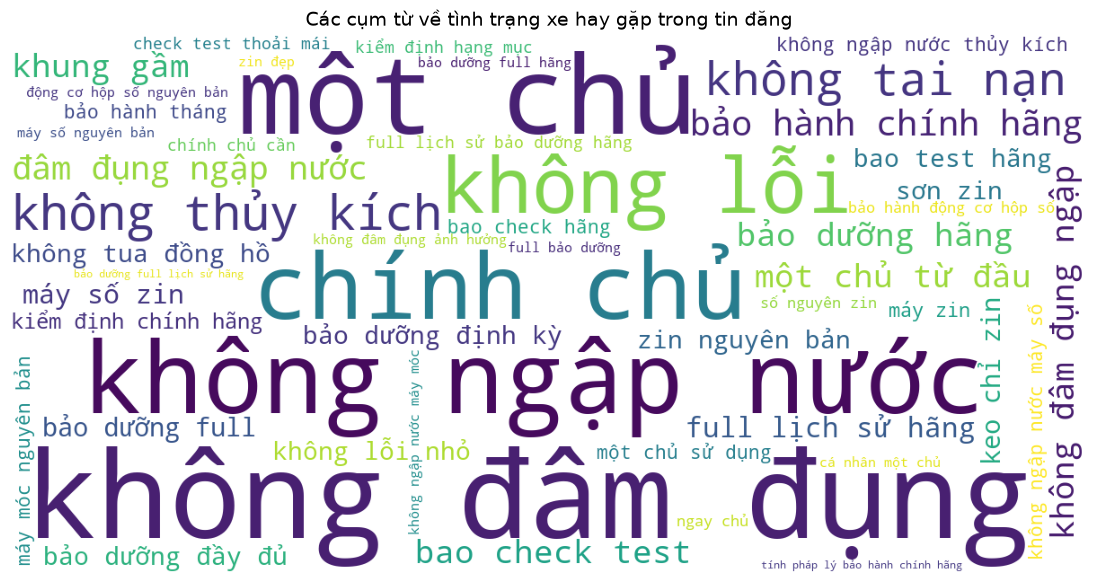

In [11]:
# vẽ 50 cụm nhiều nhất
wc = WordCloud(width=1200, height=600, background_color="white", max_words=50, random_state=42)
wc.generate_from_frequencies(cum_tinh_trang)

plt.figure(figsize=(14, 7))
plt.imshow(wc)
plt.axis("off")
plt.title("Các cụm từ về tình trạng xe hay gặp trong tin đăng", fontsize=14)
plt.show()

In [12]:
# 15 cụm nhiều nhất
bang = pd.DataFrame({
    "Cụm từ": list(cum_tinh_trang.keys()),
    "Số tin": list(cum_tinh_trang.values()),
})
bang["% tin"] = (bang["Số tin"] / len(df) * 100).round(1)
bang.head(15)

,Cụm từ,Số tin,% tin
0,không đâm đụng,2058,15.2
1,một chủ,1659,12.3
2,không ngập nước,1381,10.2
3,chính chủ,1121,8.3
4,không lỗi,771,5.7
5,không thủy kích,569,4.2
6,không tai nạn,516,3.8
7,bảo hành chính hãng,486,3.6
8,đâm đụng ngập nước,425,3.1
9,bảo dưỡng hãng,402,3.0


In [13]:
# các cụm nêu trong kế hoạch
for cum in ["keo chỉ zin", "bao test hãng", "một chủ từ đầu"]:
    print(cum, ":", dem[cum], "tin")

keo chỉ zin : 248 tin
bao test hãng : 220 tin
một chủ từ đầu : 381 tin


Nhận xét:

- Cam kết hay gặp nhất là về tai nạn và ngập nước: "không đâm đụng" có trong khoảng 15% số tin, "không ngập nước" khoảng 10%, ngoài ra còn "không thủy kích", "không tai nạn". Đây là những lỗi người mua khó tự phát hiện khi đi xem xe nên người bán phải cam kết bằng lời.
- Tiếp theo là về nguồn gốc và lịch sử xe: "một chủ", "chính chủ", "một chủ từ đầu", "bảo dưỡng hãng", "full lịch sử hãng".
- Có một nhóm về độ nguyên bản của xe: "keo chỉ zin", "sơn zin", "zin nguyên bản", "không tua đồng hồ".
- Một số tin cho người mua tự kiểm tra xe: "bao check test", "bao test hãng", "kiểm định chính hãng".

Các cụm nêu trong kế hoạch (keo chỉ zin, bao test hãng, một chủ từ đầu) đều có trong Word Cloud nhưng không phải nhiều nhất, mỗi cụm chỉ có trong chưa tới 3% số tin.

Điểm chung của các cụm trên là đều do người bán tự nói, người mua chỉ đọc tin thì không kiểm chứng được. Đây chính là bất cân xứng thông tin mà dự án đặt ra. Phần tiếp theo biến các cam kết này thành biến số để notebook 05 xem chúng có giúp dự đoán giá tốt hơn không.

## 4. Biến cờ từ văn bản

Từ các cụm ở trên, nhóm tạo 9 biến cờ (1 = tin có nhắc tới, 0 = không nhắc tới):

| Biến | Ý nghĩa |
|---|---|
| `vb_chinh_chu` | xe chính chủ, một chủ từ đầu |
| `vb_bao_duong_hang` | bảo dưỡng ở hãng, có lịch sử bảo dưỡng |
| `vb_khong_dam_dung` | cam kết không đâm đụng, không tai nạn |
| `vb_khong_ngap_nuoc` | cam kết không ngập nước, không thủy kích |
| `vb_zin` | máy số zin, keo chỉ zin, nguyên bản |
| `vb_khong_tua_odo` | cam kết không tua đồng hồ km |
| `vb_bao_test` | cho người mua kiểm tra xe: bao test, bao check, test hãng |
| `vb_tra_gop` | hỗ trợ trả góp, vay ngân hàng (hay gặp ở tin của salon) |
| `vb_bao_hanh` | xe còn bảo hành hoặc người bán có bảo hành |

Tên biến có tiền tố `vb_` (văn bản) để dễ nhận ra đây là các biến lấy từ phần chữ của tin đăng.

In [14]:
# tin chứa ít nhất 1 cụm trong danh sách thì cờ = 1
co = {
    "vb_chinh_chu": ["chính chủ", "một chủ"],
    "vb_bao_duong_hang": ["bảo dưỡng hãng", "bảo dưỡng chính hãng", "bảo dưỡng định kỳ",
                          "lịch sử hãng", "lịch sử bảo dưỡng"],
    "vb_khong_dam_dung": ["không đâm đụng", "không bị đâm đụng", "không tai nạn", "không bị tai nạn",
                          "không va chạm", "không bị va chạm", "bao đâm đụng"],
    "vb_khong_ngap_nuoc": ["không ngập", "không bị ngập", "không thủy kích", "không bị thủy kích",
                           "đâm đụng ngập"],
    "vb_zin": ["zin", "nguyên bản"],
    "vb_khong_tua_odo": ["không tua"],
    "vb_bao_test": ["bao test", "bao check", "test hãng", "check hãng", "kiểm định chính hãng",
                    "kiểm tra hãng"],
    "vb_tra_gop": ["trả góp", "vay ngân hàng", "hỗ trợ vay", "hỗ trợ ngân hàng", "hỗ trợ bank"],
    "vb_bao_hanh": ["bảo hành"],
}

for ten_co in co:
    df[ten_co] = 0
    for cum in co[ten_co]:
        co_cum_nay = df["van_ban_sach"].str.contains(cum, regex=False)
        df.loc[co_cum_nay, ten_co] = 1

In [15]:
ten_cac_co = list(co.keys())
tin_co_mo_ta = df[df["co_mo_ta"] == 1]
tin_chi_co_tieu_de = df[df["co_mo_ta"] == 0]

# cột 0/1 nên trung bình chính là tỷ lệ
ti_le = pd.DataFrame({
    "Tất cả tin (%)": df[ten_cac_co].mean() * 100,
    "Tin có mô tả (%)": tin_co_mo_ta[ten_cac_co].mean() * 100,
    "Tin chỉ có tiêu đề (%)": tin_chi_co_tieu_de[ten_cac_co].mean() * 100,
})
ti_le.round(1)

,Tất cả tin (%),Tin có mô tả (%),Tin chỉ có tiêu đề (%)
vb_chinh_chu,21.8,29.6,3.4
vb_bao_duong_hang,9.0,12.8,0.1
vb_khong_dam_dung,20.2,28.7,0.0
vb_khong_ngap_nuoc,20.2,28.8,0.0
vb_zin,26.5,37.1,1.6
vb_khong_tua_odo,3.2,4.6,0.0
vb_bao_test,11.4,16.2,0.2
vb_tra_gop,13.1,18.3,0.9
vb_bao_hanh,12.0,16.8,0.6


In [16]:
# mỗi cờ 1 ví dụ, lấy từ các tin khác nhau, cắt khoảng 40 ký tự quanh chỗ tìm thấy
pd.set_option("display.max_colwidth", 120)

vi_du = []
tin_da_dung = []
for ten_co in co:
    cac_tin = df[(df["co_mo_ta"] == 1) & (df[ten_co] == 1)]
    for chi_so in cac_tin.index:
        if chi_so in tin_da_dung:
            continue
        text = df.loc[chi_so, "van_ban_sach"]

        for cum in co[ten_co]:
            vi_tri = text.find(cum)
            if vi_tri != -1:
                break

        bat_dau = max(0, vi_tri - 40)
        ket_thuc = vi_tri + len(cum) + 40
        vi_du.append([ten_co, "..." + text[bat_dau:ket_thuc] + "..."])
        tin_da_dung.append(chi_so)
        break

pd.DataFrame(vi_du, columns=["Biến", "Ví dụ"])

,Biến,Ví dụ
0,vb_chinh_chu,... đặc biệt ath công chức sử dụng tư nhân chính chủ đẹp zin không lỗi máy số nguyên bản khô...
1,vb_bao_duong_hang,...e cao cấp gầm cao cho mọi gd xe một chủ bảo dưỡng hãng đầy đủ kiểu dáng sang trọng chất lượng ...
2,vb_khong_dam_dung,...model máy móc nguyên zin bao check hãng bao đâm đụng ngập nước isuzu dmax model số tự động x...
3,vb_khong_ngap_nuoc,...p một chủ zin cả xe nội thất nguyên bản không ngập nước hay tai nạn chỉ bàn về giá thôi ạ ...
4,vb_zin,...ố sàn máy gioăng máy tất cả keo chỉ cửa zin nguyên bản khoang máy cũ bụi theo thời ...
5,vb_khong_tua_odo,... đoan xe không đâm đụng không ngập nước không tua đồng hồ động cơ nguyên zin nắp cò chưa ...
6,vb_bao_test,...ng km thay nhớt một lần miễn phí hỗ trợ test hãng có văn bản...
7,vb_tra_gop,...m bảo hành ở các vi trí xung yếu hỗ trợ vay ngân hàng lãi suất ưu đãi bảo hành tháng động cơ ...
8,vb_bao_hanh,...fortuner at model bảo hành năm fortuner v số tự động xăng model ph...


Nhận xét:

- Với các tin có mô tả, cờ phổ biến nhất là `vb_zin` (khoảng 37%), sau đó là `vb_chinh_chu`, `vb_khong_dam_dung`, `vb_khong_ngap_nuoc` (khoảng 29%).
- Với các tin chỉ có tiêu đề thì gần như cờ nào cũng bằng 0, vì tiêu đề quá ngắn, người bán không ghi cam kết vào đó. Đây là giới hạn đã nêu trong proposal (khoảng 30% tin không lấy được mô tả). Khi đưa vào mô hình nên dùng kèm cột `co_mo_ta` để mô hình phân biệt được tin "không cam kết" với tin "không có mô tả nên không biết".
- Cách tìm này chỉ so khớp theo chữ, không hiểu ngữ cảnh. Ví dụ "bảo hành" có thể là xe còn bảo hành chính hãng hoặc salon bảo hành vài tháng, cả 2 trường hợp đều được tính là 1.

## 5. Lưu kết quả

File `data/processed/text_flags.csv` gồm `list_id`, `co_mo_ta` và 9 cờ. Notebook 05 nối file này vào dữ liệu sạch theo `list_id` để thêm đặc trưng cho mô hình.

In [17]:
cot_luu = ["list_id", "co_mo_ta"] + ten_cac_co
df[cot_luu].to_csv(FLAGS_PATH, index=False)

# đọc lại để kiểm tra
kiem_tra = pd.read_csv(FLAGS_PATH)
print("Đã lưu", FLAGS_PATH, ":", len(kiem_tra), "dòng,", len(kiem_tra.columns), "cột")
print("list_id không bị trùng:", kiem_tra["list_id"].is_unique)
print("Số dòng bằng dữ liệu sạch:", len(kiem_tra) == len(df))

Đã lưu ../data/processed/text_flags.csv : 13520 dòng, 11 cột
list_id không bị trùng: True
Số dòng bằng dữ liệu sạch: True


## 6. Kết luận

- Trong tin đăng, người bán chủ yếu cam kết về tai nạn, ngập nước, nguồn gốc xe (một chủ, chính chủ) và độ nguyên bản (zin). Đây đều là thông tin người mua khó tự kiểm chứng.
- Đã tạo 9 biến cờ và lưu ở `data/processed/text_flags.csv` (13.520 dòng, khớp với dữ liệu sạch theo `list_id`) để notebook 05 thử thêm vào mô hình.
- Giới hạn: khoảng 30% tin chỉ có tiêu đề nên cờ gần như bằng 0; cách tìm theo chữ không hiểu ngữ cảnh; cam kết trong tin chưa chắc đã đúng sự thật.